---
title: "5. Cokriging"
execute:
  enabled: false
---


# 5. Cokriging 



**Dataset:** Jura geochemical survey (`data/jura_data.csv`, `data/jura_grid.csv`)  

**Primary:** Cadmium (Cd, mg/kg)

**Secondaries:** Zinc (Zn, mg/kg) and Nickel (Ni, mg/kg)

**Library:** `pygstat` v0.1.0  



***

## Table of Contents

1. [Overview](#1-overview)
2. [What is Cokriging?](#2-what-is-cokriging)
3. [How Full and Colocated Cokriging Work](#3-how-full-and-colocated-cokriging-work)
4. [Python Setup](#4-python-setup)
   - 4.1 [CPU and GPU](#41-cpu-and-gpu)
5. [Load and Explore the Jura Data](#5-load-and-explore-the-jura-data)
6. [Stratified Train / Test Split](#6-stratified-train--test-split)
7. [Multivariate Exploratory Analysis](#7-multivariate-exploratory-analysis)
8. [Linear Model of Coregionalization](#8-linear-model-of-coregionalization)
9. [Ordinary Kriging Baseline](#9-ordinary-kriging-baseline)
10. [Full Cokriging](#10-full-cokriging)
11. [Validate Full Cokriging](#11-validate-full-cokriging)
12. [Colocated Cokriging](#12-colocated-cokriging)
13. [Validate Colocated Cokriging](#13-validate-colocated-cokriging)
14. [Heterotopic Sampling](#14-heterotopic-sampling)
15. [Compare Methods](#15-compare-methods)
16. [Predict Cd on the Jura Grid](#16-predict-cd-on-the-jura-grid)
17. [Map Predicted Concentration and Error](#17-map-predicted-concentration-and-error)
18. [Probability Maps of Exceedance](#18-probability-maps-of-exceedance)
19. [CPU vs GPU Cokriging Timing](#19-cpu-vs-gpu-cokriging-timing)
20. [Summary and Conclusions](#20-summary-and-conclusions)
21. [Resources](#21-resources)


***
## 1. Overview

**Cokriging** is multivariate kriging: it predicts a **primary** variable using its own samples **and** one or more **secondary** variables that are spatially correlated with it. When the secondary is cheaper, denser, or exhaustive (known at every prediction node), cokriging can beat ordinary kriging of the primary alone.

This tutorial predicts **cadmium (Cd)** in the Swiss Jura with **zinc (Zn)** and **nickel (Ni)** as covariates — the classic multivariate example of Goovaerts (1997) — using the same Landuse-stratified split as Tutorials 03–05:

| Step | What we do |
|------|------------|
| Data | Load `jura_data.csv` (359 samples of Cd, Zn, Ni) and `jura_grid.csv` (prediction nodes) |
| Split | Stratified 70% / 30% train–test split by **Landuse** (`random_state=42`) |
| EDA | Scatterplots, Pearson correlations, and side-by-side maps of Cd, Zn, Ni |
| LMC | Fit auto- and cross-variograms under a **linear model of coregionalization** |
| Baseline | Ordinary kriging of Cd (univariate) |
| Full cokriging | `MultivariateCokriging` using Cd, Zn, and Ni at training locations |
| Colocated cokriging | Markov-model (MM1) cokriging using Zn and Ni **at the prediction location** |
| Heterotopic test | Undersample training Cd; keep Zn and Ni dense — the setting where cokriging helps most |
| Mapping | Predict Cd (and kriging SE) on the Jura grid; map Gaussian exceedance probabilities |
| CPU / GPU | Time `MultivariateCokriging.predict` on CPU vs GPU for Jura Cd–Zn–Ni and a simulated Jura-like survey ($n=6{,}000$) |

By the end you will have compared ordinary kriging, full cokriging, and colocated cokriging, mapped Cd with both estimators, and seen when a GPU pays off for full cokriging.


***
## 2. What is Cokriging?

Univariate kriging predicts $Z_1(\mathbf{x}_0)$ from samples of $Z_1$ only. Cokriging adds secondary fields $Z_2, Z_3, \ldots$ that share spatial structure with $Z_1$:

$$
\hat{Z}_1(\mathbf{x}_0)
= \sum_{i=1}^{n_1} \lambda_{1i}\, Z_1(\mathbf{x}_{1i})
+ \sum_{k=2}^{p}\sum_{j=1}^{n_k} \lambda_{kj}\, Z_k(\mathbf{x}_{kj}).
$$

**Ordinary cokriging** enforces unbiasedness when the means are unknown constants:

$$
\sum_{i} \lambda_{1i} = 1, \qquad
\sum_{j} \lambda_{kj} = 0 \quad (k = 2,\ldots,p).
$$

The secondary weights sum to **zero**, so a secondary contributes only through its *spatial contrast*, not by shifting the global mean of Cd.

### When cokriging helps

| Situation | Why secondaries help |
|-----------|----------------------|
| **Heterotopic sampling** | Cd is sparse; Zn / Ni are denser (or exhaustive) |
| Strong cross-correlation | Cd–Zn and Cd–Ni $r \approx 0.5$–$0.6$ in the Jura |
| Exhaustive secondary | A covariate is known at every grid node (e.g. a remote-sensing map) |
| **Isotopic sampling** | All variables at the same sites — full cokriging is often close to OK |

### Full vs colocated vs ordinary kriging

| | Ordinary Kriging | Full cokriging | Colocated cokriging |
|---|---|---|---|
| Data at $\mathbf{x}_0$ | none | none required | **secondary must be known** |
| Secondary samples | unused | **all** secondary locations | typically **only** $Z_k(\mathbf{x}_0)$ |
| System size | $n_1+1$ | $\sum n_k + p$ | $n_1 + p_{\text{sec}} + 1$ |
| Cross-variograms | no | full LMC | MM1 screening approximation |
| Best for | univariate mapping | heterotopic networks | exhaustive secondaries |

### Assumptions

| Assumption | Meaning |
|------------|---------|
| Joint second-order stationarity | Each $Z_k$ has a covariance, and every pair has a cross-covariance |
| LMC | All auto- and cross-variograms share the same basic nested structures |
| PSD coregionalization | Nugget and sill matrices $\mathbf{B}_0, \mathbf{B}_1$ are positive semi-definite |
| MM1 (colocated only) | The primary **screens** farther secondary data: $C_{1k}(h)=\dfrac{C_{1k}(0)}{C_{11}(0)}C_{11}(h)$ |


***
## 3. How Full and Colocated Cokriging Work

### 3.1 Cross-variogram

For colocated samples of $Z_1$ and $Z_2$, the Matheron cross-variogram is

$$
\hat{\gamma}_{12}(h)
= \frac{1}{2N(h)}\sum_{\alpha=1}^{N(h)}
\bigl[Z_1(\mathbf{x}_\alpha)-Z_1(\mathbf{x}_\alpha+\mathbf{h})\bigr]
\bigl[Z_2(\mathbf{x}_\alpha)-Z_2(\mathbf{x}_\alpha+\mathbf{h})\bigr].
$$

Unlike an auto-variogram, $\gamma_{12}$ **may be negative** (negative cross-correlation). Under second-order stationarity

$$
C_{12}(h) = C_{12}(0) - \gamma_{12}(h), \qquad C_{12}(0)=\text{nugget}_{12}+c_{12}.
$$

### 3.2 Linear model of coregionalization (LMC)

A one-structure LMC writes every auto- and cross-variogram with the **same** basic shape $g(h)$ (spherical, exponential, …) and a **common range**:

$$
\gamma_{ij}(h) = b_{ij}^{(0)} + b_{ij}^{(1)}\, g(h).
$$

The nugget matrix $\mathbf{B}_0=[b_{ij}^{(0)}]$ and the partial-sill matrix $\mathbf{B}_1=[b_{ij}^{(1)}]$ must be positive semi-definite (Cauchy–Schwarz on every pair, and all eigenvalues $\ge 0$). `pygstat.fit_lmc` fits the auto-variograms, locks a shared range, fits the cross-sills, and clips them to the Cauchy–Schwarz bounds.

### 3.3 Full ordinary cokriging

Stack all training values $\mathbf{z}=(\mathbf{z}_1^\top,\mathbf{z}_2^\top,\mathbf{z}_3^\top)^\top$ and the block covariance $\mathbf{C}$. With constraint matrix $\mathbf{F}$ (a column of ones per variable),

$$
\begin{bmatrix} \mathbf{C} & \mathbf{F} \\ \mathbf{F}^\top & \mathbf{0} \end{bmatrix}
\begin{bmatrix} \boldsymbol{\lambda} \\ \boldsymbol{\mu} \end{bmatrix}
=
\begin{bmatrix} \mathbf{c}_0 \\ \mathbf{f}_0 \end{bmatrix},
\quad
\mathbf{f}_0=(1,0,0)^\top
$$

when predicting $Z_1$. Then $\hat{Z}_1(\mathbf{x}_0)=\boldsymbol{\lambda}^\top\mathbf{z}$ and

$$
\sigma^2_{\text{CK}}(\mathbf{x}_0)=C_{11}(0)-\boldsymbol{\lambda}^\top\mathbf{c}_0-\mu_1.
$$

`MultivariateCokriging` allows **heterotopic** networks: Cd, Zn, and Ni may have different sample locations.

### 3.4 Colocated cokriging (MM1)

Xu, Tran, Srivastava & Journel (1992) retain only the **colocated** secondary $Y_k(\mathbf{x}_0)$. The Markov screening model sets

$$
C_{1k}(h)=\frac{C_{1k}(0)}{C_{11}(0)}\, C_{11}(h).
$$

The ordinary colocated predictor used here treats secondary means as known (residual secondaries) and keeps $\sum_i\lambda_i=1$ on the primary:

$$
\hat{Z}_1(\mathbf{x}_0)
= \sum_{i=1}^{n_1}\lambda_i Z_1(\mathbf{x}_i)
+ \sum_{k}\lambda_k^c \bigl[Y_k(\mathbf{x}_0)-m_k\bigr].
$$

`jura_grid.csv` has no Zn or Ni, so for mapping we first ordinary-krige Zn and Ni onto the grid and then run colocated cokriging of Cd. On the test set we can use the **observed** Zn and Ni (exhaustive-secondary validation).

### 3.5 Gaussian exceedance probability

$$
P\bigl(\text{Cd}(\mathbf{x}_0)>z_c\bigr)
= 1-\Phi\!\left(\frac{z_c-\hat{Z}(\mathbf{x}_0)}{\sigma(\mathbf{x}_0)}\right).
$$

### 3.6 Workflow in this notebook

1. Split samples **by Landuse**.
2. Rank Cd auto-variogram models by AIC; fit an LMC for Cd, Zn, Ni with that structure.
3. Fit OK, full cokriging, and colocated cokriging on the training set.
4. Validate all three on the test set; repeat with undersampled Cd (heterotopic).
5. Map the grid; compute $P(\text{Cd}>z_c)$.


***
## 4. Python Setup

### 4.1 CPU and GPU

PyGStat's `MultivariateCokriging` (and `Cokriging`, `ColocatedCokriging`, `OrdinaryKriging`) builds the covariance matrix and solves the kriging system on **CPU** (NumPy/SciPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. The cokriging and OK fits below pass `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

Two caveats:

- Full cokriging's system is $(\sum n_k + p) \times (\sum n_k + p)$ for $p$ variables. On an isotopic network that is about $p\,n$, so GPU memory and the $O((pn)^3)$ factor grow faster than univariate OK.
- **Small $n$** (a few hundred training points, like Jura) often shows little GPU gain *unless* you predict a large grid.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 19 times `MultivariateCokriging.predict` on both backends using Jura Cd–Zn–Ni and a simulated Jura-like bivariate survey with $n=6{,}000$.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, pearsonr
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pygstat
from pygstat import (
    Variogram, OrdinaryKriging,
    MultivariateCokriging, ColocatedCokriging, fit_lmc,
)
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — cokriging covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788925389.481502  551534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pygstat version : 0.1.0
NumPy           : 2.4.6
pandas          : 3.0.3
CuPy            : 14.2.0
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — cokriging covariance + solve on GPU
use_gpu         : True


***
## 5. Load and Explore the Jura Data

The **Jura dataset** (Goovaerts, 1997) contains 359 soil samples of heavy metals in the Swiss Jura. We predict **Cd** using **Zn** and **Ni** as secondary variables, and map it on `jura_grid.csv`.

Land-use codes in the sample file are integers (`1`–`4`). The stratified split uses that integer column. The prediction grid has coordinates and land-use / rock labels but **no metal concentrations** — full cokriging does not need metals on the grid; colocated cokriging will require us to interpolate Zn and Ni first.


In [2]:
df = pd.read_csv("../data/jura_data.csv")
grid = pd.read_csv("../data/jura_grid.csv")

print("Samples:", df.shape, "  Grid:", grid.shape)
print("Sample columns:", list(df.columns))
print("Grid columns:  ", list(grid.columns))
df.head()


Samples: (359, 12)   Grid: (5957, 5)
Sample columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
primary = "Cd"
secondaries = ["Zn", "Ni"]
metals = [primary] + secondaries
x_col, y_col = "Xloc", "Yloc"
strata_col = "Landuse"

coords = df[[x_col, y_col]].values
grid_coords = grid[[x_col, y_col]].values

print("Metal summaries (mg/kg)\n")
print(df[metals].describe().round(3).to_string())
print("\nSkewness:")
for col in metals:
    print(f"  {col:3s}: {skew(df[col].values.astype(float)):.3f}")
print(f"\nLanduse counts:\n{df[strata_col].value_counts().sort_index().to_string()}")


Metal summaries (mg/kg)

            Cd       Zn       Ni
count  359.000  359.000  359.000
mean     1.288   75.882   20.018
std      0.859   30.819    8.094
min      0.135   25.000    1.980
25%      0.653   54.600   14.600
50%      1.100   73.560   20.680
75%      1.680   90.000   25.380
max      5.129  259.840   53.200

Skewness:
  Cd : 1.472
  Zn : 1.487
  Ni : 0.110

Landuse counts:
Landuse
1     51
2     82
3    218
4      8


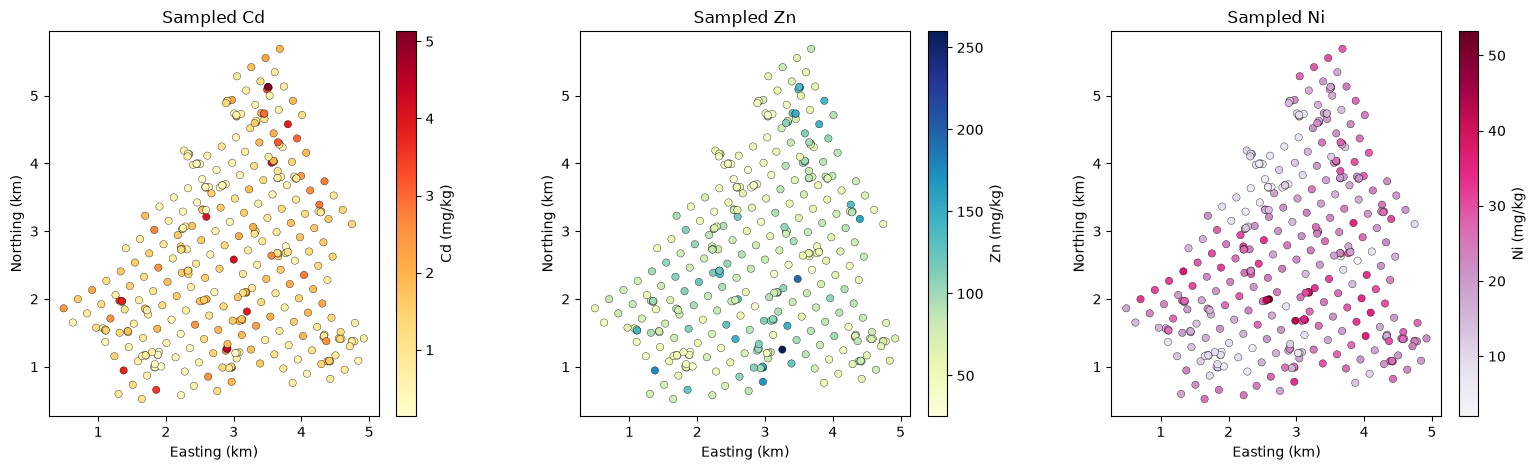

Grid extent: X [0.30, 5.10], Y [0.10, 5.90] km  (5957 nodes)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
cmaps = ["YlOrRd", "YlGnBu", "PuRd"]
for ax, col, cmap in zip(axes, metals, cmaps):
    z = df[col].values.astype(float)
    sc = ax.scatter(df[x_col], df[y_col], c=z, cmap=cmap, s=28,
                    edgecolors="k", linewidths=0.25)
    plt.colorbar(sc, ax=ax, label=f"{col} (mg/kg)", fraction=0.046, pad=0.04)
    ax.set_title(f"Sampled {col}")
    ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"Grid extent: X [{grid[x_col].min():.2f}, {grid[x_col].max():.2f}], "
      f"Y [{grid[y_col].min():.2f}, {grid[y_col].max():.2f}] km  ({len(grid)} nodes)")


***
## 6. Stratified Train / Test Split

**Stratified random sampling** draws the 70% / 30% split inside each Landuse class. Variograms, the LMC, and all kriging models are fitted on the **training** set only. The split seed matches Tutorials 03–05 (`random_state=42`).


In [5]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(sss.split(df, df[strata_col]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

coords_train = df_train[[x_col, y_col]].values
coords_test  = df_test[[x_col, y_col]].values
z_train = {col: df_train[col].values.astype(float) for col in metals}
z_test  = {col: df_test[col].values.astype(float) for col in metals}

print(f"Train: {len(df_train)} ({100*len(df_train)/len(df):.1f}%)")
print(f"Test:  {len(df_test)} ({100*len(df_test)/len(df):.1f}%)")

prop = pd.DataFrame({
    "all":    df[strata_col].value_counts(normalize=True).sort_index(),
    "train":  df_train[strata_col].value_counts(normalize=True).sort_index(),
    "test":   df_test[strata_col].value_counts(normalize=True).sort_index(),
})
prop.index.name = "Landuse"
(prop * 100).round(1)


Train: 251 (69.9%)
Test:  108 (30.1%)


,all,train,test
Landuse,,,
1,14.2,14.3,13.9
2,22.8,22.7,23.1
3,60.7,60.6,61.1
4,2.2,2.4,1.9


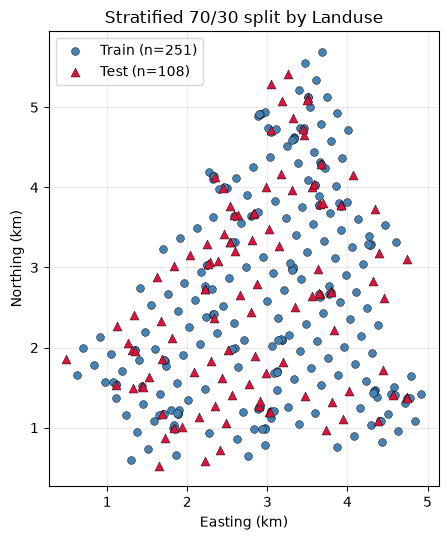

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(df_train[x_col], df_train[y_col], c="steelblue", s=32,
           edgecolors="k", linewidths=0.3, label=f"Train (n={len(df_train)})", zorder=3)
ax.scatter(df_test[x_col], df_test[y_col], c="crimson", s=42, marker="^",
           edgecolors="k", linewidths=0.3, label=f"Test (n={len(df_test)})", zorder=4)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title("Stratified 70/30 split by Landuse")
ax.legend(frameon=True); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


***
## 7. Multivariate Exploratory Analysis

Cokriging is worthwhile only if the secondaries are **linearly related** to Cd *and* share spatial patterns. We inspect Pearson correlations, scatterplots, and the training maps.


In [7]:
corr = df_train[metals].corr()
print("Pearson correlation (training)\n")
print(corr.round(3).to_string())
print()
for a, b in [("Cd", "Zn"), ("Cd", "Ni"), ("Zn", "Ni")]:
    r, p = pearsonr(z_train[a], z_train[b])
    print(f"  {a}–{b}:  r = {r:.3f}   p = {p:.2e}")


Pearson correlation (training)

       Cd     Zn     Ni
Cd  1.000  0.622  0.503
Zn  0.622  1.000  0.582
Ni  0.503  0.582  1.000

  Cd–Zn:  r = 0.622   p = 2.98e-28
  Cd–Ni:  r = 0.503   p = 1.82e-17
  Zn–Ni:  r = 0.582   p = 3.75e-24


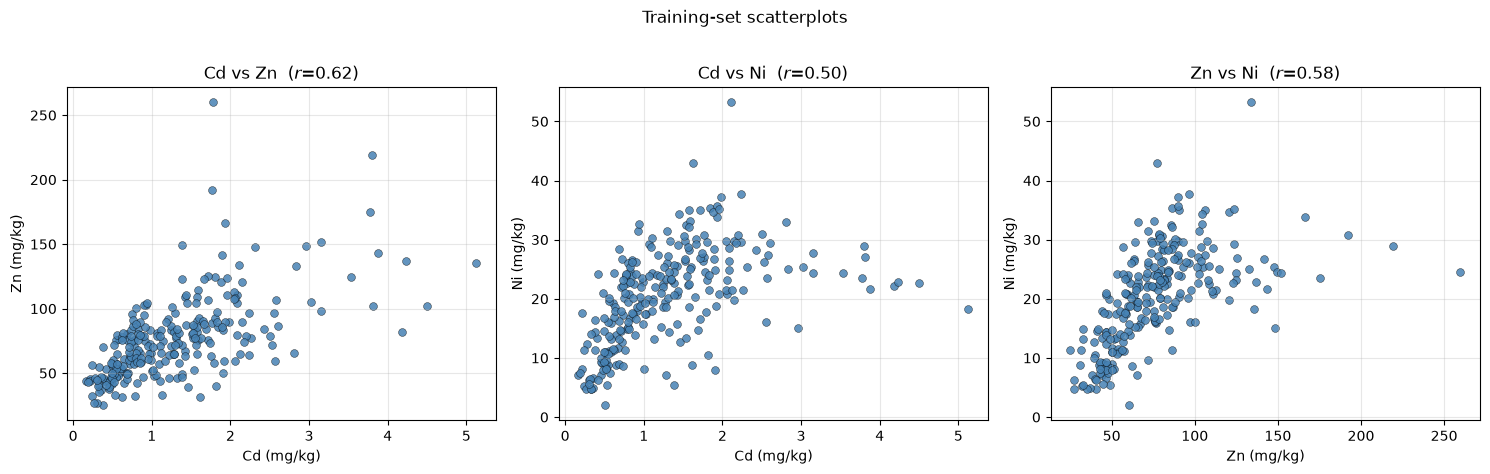

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
pairs = [("Cd", "Zn"), ("Cd", "Ni"), ("Zn", "Ni")]
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(z_train[a], z_train[b], c="steelblue", edgecolors="k",
               linewidths=0.3, s=32, alpha=0.85)
    r = corr.loc[a, b]
    ax.set_xlabel(f"{a} (mg/kg)"); ax.set_ylabel(f"{b} (mg/kg)")
    ax.set_title(f"{a} vs {b}  ($r$={r:.2f})")
    ax.grid(alpha=0.3)
plt.suptitle("Training-set scatterplots", y=1.02)
plt.tight_layout(); plt.show()


Cd is right-skewed and moderately correlated with both Zn ($r\approx 0.62$ on the full survey) and Ni ($r\approx 0.49$). Those values are large enough for cokriging to matter **when the secondary is denser than Cd**. On a fully isotopic network the gain is usually small — we will see that explicitly.


***
## 8. Linear Model of Coregionalization

We first pick the best **Cd auto-variogram** model by AIC (same six models as Tutorials 02–05). All LMC structures then share that model and a common range.


In [9]:
def find_best_variogram(coords, values, estimator="matheron", n_lags=15,
                        criterion="AIC", verbose=True):
    """Fit all standard models; return the best Variogram by ``criterion``."""
    models = ["spherical", "exponential", "gaussian", "matern", "stable", "cubic"]
    n_params = {"spherical": 3, "exponential": 3, "gaussian": 3,
                "matern": 4, "stable": 4, "cubic": 3}
    fitted, records = {}, []

    for model_name in models:
        v = Variogram(coords=np.asarray(coords, dtype=float),
                      values=np.asarray(values, dtype=float),
                      model=model_name, estimator=estimator, n_lags=n_lags)
        v.fit()
        obs = v.experimental
        mask = ~np.isnan(obs)
        obs_v, pred = obs[mask], v(v.lags)[mask]
        K, p = mask.sum(), n_params[model_name]
        rss = float(np.sum((pred - obs_v) ** 2))
        tss = float(np.sum((obs_v - obs_v.mean()) ** 2))
        r2 = 1.0 - rss / tss if tss > 0 else np.nan
        aic = K * np.log(rss / K) + 2 * p if rss > 0 else -np.inf
        bic = K * np.log(rss / K) + p * np.log(K) if rss > 0 else -np.inf
        fitted[model_name] = v
        extra = round(float(v.fitted_params[3]), 4) if len(v.fitted_params) > 3 else "—"
        records.append({
            "Model": model_name.capitalize(),
            "Nugget": round(float(v.fitted_params[0]), 5),
            "Sill":   round(float(v.fitted_params[1]), 5),
            "Range":  round(float(v.fitted_params[2]), 5),
            "Extra":  extra,
            "RSS":    round(rss, 6),
            "R²":     round(r2, 4),
            "AIC":    round(aic, 4),
            "BIC":    round(bic, 4),
        })

    df_results = pd.DataFrame(records).set_index("Model")
    df_results = df_results.sort_values(criterion, ascending=(criterion != "R²"))
    best_cap = df_results.index[0]
    if verbose:
        print(df_results.to_string())
        print(f"\n>>> BEST Cd MODEL: {best_cap} (by {criterion}) <<<")
    return best_cap, fitted[best_cap.lower()], df_results, fitted


print("Fitting Cd auto-variograms on the training set\n")
best_name, vg_cd, df_rank, fitted_cd = find_best_variogram(
    coords_train, z_train["Cd"], estimator="matheron", n_lags=12, criterion="AIC"
)
lmc_model = best_name.lower()
df_rank.style.background_gradient(subset=["AIC", "RSS"], cmap="RdYlGn_r")


Fitting Cd auto-variograms on the training set

              Nugget     Sill    Range   Extra       RSS      R²      AIC      BIC
Model                                                                             
Spherical    0.56002  0.15320  1.75505       —  0.032596  0.4580 -64.9017 -63.4470
Cubic        0.57964  0.13343  2.06349       —  0.033115  0.4494 -64.7121 -63.2574
Exponential  0.54989  0.19668  0.97775       —  0.033137  0.4490 -64.7041 -63.2493
Gaussian     0.57923  0.13395  0.84831       —  0.033317  0.4460 -64.6390 -63.1842
Matern       0.56645  0.15393  0.39814  1.3931  0.032745  0.4555 -62.8469 -60.9073
Stable       0.56456  0.15532  0.81914  1.4358  0.032843  0.4539 -62.8111 -60.8715

>>> BEST Cd MODEL: Spherical (by AIC) <<<


,Nugget,Sill,Range,Extra,RSS,R²,AIC,BIC
Model,,,,,,,,
Spherical,0.560020,0.153200,1.755050,—,0.032596,0.458000,-64.901700,-63.447000
Cubic,0.579640,0.133430,2.063490,—,0.033115,0.449400,-64.712100,-63.257400
Exponential,0.549890,0.196680,0.977750,—,0.033137,0.449000,-64.704100,-63.249300
Gaussian,0.579230,0.133950,0.848310,—,0.033317,0.446000,-64.639000,-63.184200
Matern,0.566450,0.153930,0.398140,1.393100,0.032745,0.455500,-62.846900,-60.907300
Stable,0.564560,0.155320,0.819140,1.435800,0.032843,0.453900,-62.811100,-60.871500


In [10]:
print(f"Fitting 1-structure LMC ({lmc_model}) for Cd, Zn, Ni\n")
vgs, cross, lmc_info = fit_lmc(
    coords_train,
    [z_train["Cd"], z_train["Zn"], z_train["Ni"]],
    names=["Cd", "Zn", "Ni"],
    model=lmc_model,
    n_lags=12,
    shared_range=True,
)

print(f"Shared range : {lmc_info['range']:.4f} km")
print(f"LMC valid    : {lmc_info['lmc_check']['valid']}")
print(f"Sill eigs    : {np.round(lmc_info['lmc_check']['sill_eigs'], 5)}")
print(f"Nugget eigs  : {np.round(lmc_info['lmc_check']['nugget_eigs'], 5)}")
print("\nNugget matrix B0")
print(pd.DataFrame(np.round(lmc_info["nugget_matrix"], 4),
                   index=lmc_info["names"], columns=lmc_info["names"]).to_string())
print("\nPartial-sill matrix B1")
print(pd.DataFrame(np.round(lmc_info["sill_matrix"], 4),
                   index=lmc_info["names"], columns=lmc_info["names"]).to_string())


Fitting 1-structure LMC (spherical) for Cd, Zn, Ni

Shared range : 1.5211 km
LMC valid    : True
Sill eigs    : [4.198000e-02 3.309856e+01 6.789176e+02]
Nugget eigs  : [3.2728000e-01 1.2997130e+01 4.9858028e+02]

Nugget matrix B0
         Cd        Zn       Ni
Cd   0.5540   10.0465   1.3505
Zn  10.0465  495.0526  40.0173
Ni   1.3505   40.0173  16.2980

Partial-sill matrix B1
        Cd        Zn        Ni
Cd  0.1521    6.8635    2.6511
Zn  6.8635  645.6672  142.5527
Ni  2.6511  142.5527   66.2388


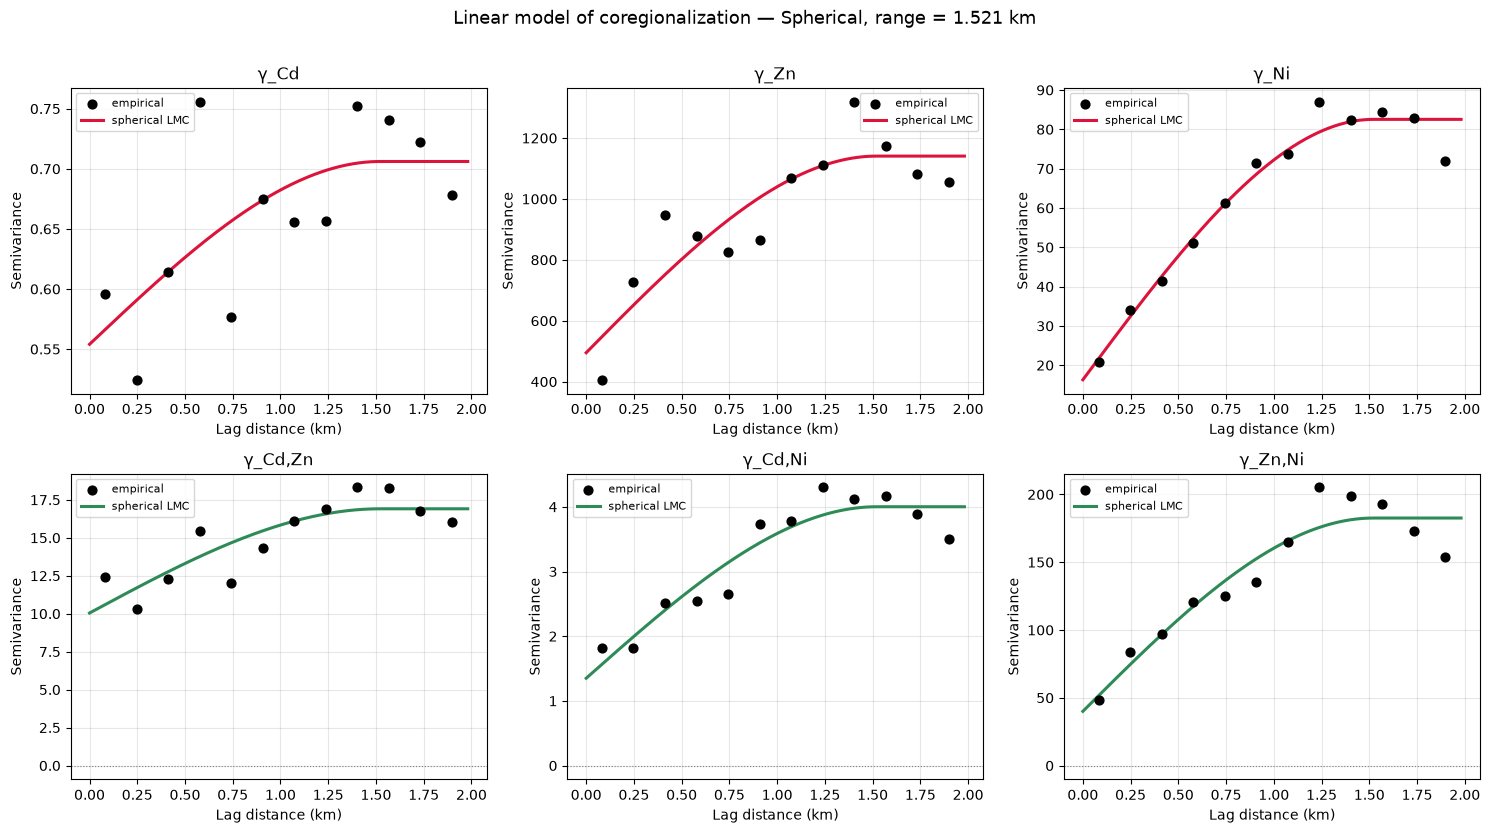

In [11]:
h_fine = np.linspace(0, vgs[0].maxlag, 300)
pair_idx = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]
titles = ["γ_Cd", "γ_Zn", "γ_Ni", "γ_Cd,Zn", "γ_Cd,Ni", "γ_Zn,Ni"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.2))
axes = axes.ravel()
for ax, (i, j), title in zip(axes, pair_idx, titles):
    if i == j:
        vg = vgs[i]
        ax.scatter(vg.lags, vg.experimental, c="k", s=40, zorder=5, label="empirical")
        ax.plot(h_fine, vg(h_fine), color="crimson", lw=2.2, label=f"{lmc_model} LMC")
    else:
        cv = cross[(i, j)]
        ax.scatter(cv.lags, cv.experimental, c="k", s=40, zorder=5, label="empirical")
        ax.plot(h_fine, cv(h_fine), color="seagreen", lw=2.2, label=f"{lmc_model} LMC")
        ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.set_title(title)
    ax.set_xlabel("Lag distance (km)")
    ax.set_ylabel("Semivariance")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f"Linear model of coregionalization — {best_name}, range = {lmc_info['range']:.3f} km",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


A valid LMC (all eigenvalues of $\mathbf{B}_0$ and $\mathbf{B}_1$ non-negative) guarantees that the cokriging covariance matrix is positive definite. The off-diagonal sills should have the same sign as the Pearson correlations: positive for Cd–Zn, Cd–Ni, and Zn–Ni.


***
## 9. Ordinary Kriging Baseline

Univariate ordinary kriging of training Cd is the reference. If full cokriging cannot beat this on an **isotopic** network, that is expected — the secondaries carry little extra information when they are sampled at the same sites as Cd.


In [12]:
ok = OrdinaryKriging(vgs[0], use_gpu=USE_GPU).fit(coords_train, z_train["Cd"])

print("Estimator               : Ordinary Kriging")
print(f"Variogram               : {vgs[0].model}")
print(f"Fitted params [C0, C, a]: {np.round(vgs[0].fitted_params[:3], 5)}")
print(f"Training n              : {len(z_train['Cd'])}")


Estimator               : Ordinary Kriging
Variogram               : spherical
Fitted params [C0, C, a]: [0.55402 0.15209 1.52107]
Training n              : 251
use_gpu                : True


In [13]:
ok_hat, ok_se = ok.predict(coords_test, return_variance=True)


def metrics_row(name, y_true, y_hat, se=None, extra=None):
    row = {
        "method": name,
        "n_test": len(y_true),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_hat))), 4),
        "MAE":  round(float(mean_absolute_error(y_true, y_hat)), 4),
        "ME":   round(float(np.mean(y_hat - y_true)), 4),
        "R2":   round(float(r2_score(y_true, y_hat)), 4),
    }
    if se is not None:
        row["mean_SE"] = round(float(np.mean(se)), 4)
    if extra:
        row.update(extra)
    return row


ok_row = metrics_row("Ordinary kriging (Cd)", z_test["Cd"], ok_hat, ok_se,
                     extra={"n_primary": len(z_train["Cd"]), "n_Zn": 0, "n_Ni": 0})
print("Ordinary Kriging — test-set validation")
print("=" * 44)
for k, v in ok_row.items():
    print(f"  {k:12s}: {v}")


Ordinary Kriging — test-set validation
  method      : Ordinary kriging (Cd)
  n_test      : 108
  RMSE        : 0.797
  MAE         : 0.5879
  ME          : 0.0043
  R2          : 0.195
  mean_SE     : 0.7872
  n_primary   : 251
  n_Zn        : 0
  n_Ni        : 0


***
## 10. Full Cokriging

`MultivariateCokriging` uses **all** training Cd, Zn, and Ni. Sampling may be heterotopic; here the three metals are isotopic on the training set (same coordinates). The primary is Cd (index 0).


In [14]:
ck_full = MultivariateCokriging(vgs, cross, use_gpu=USE_GPU).fit(
    [coords_train, coords_train, coords_train],
    [z_train["Cd"], z_train["Zn"], z_train["Ni"]],
)

print("Estimator               : Full ordinary cokriging")
print(f"Variables               : Cd (primary), Zn, Ni")
print(f"LMC model / range       : {lmc_model} / {lmc_info['range']:.4f} km")
print(f"n Cd, Zn, Ni            : {len(z_train['Cd'])}, {len(z_train['Zn'])}, {len(z_train['Ni'])}")
print(f"Kriging matrix size     : {ck_full._n + ck_full.n_var}  "
      f"({ck_full._n} covariances + {ck_full.n_var} constraints)")
print(f"use_gpu                : {ck_full.use_gpu}")


Estimator               : Full ordinary cokriging
Variables               : Cd (primary), Zn, Ni
LMC model / range       : spherical / 1.5211 km
n Cd, Zn, Ni            : 251, 251, 251
Kriging matrix size     : 756  (753 covariances + 3 constraints)
use_gpu                : True


***
## 11. Validate Full Cokriging

Predict Cd at the held-out 30% of samples. Full cokriging does **not** use test-set Zn or Ni — only training secondaries — so this is a fair isotopic comparison with OK.


In [15]:
full_hat, full_se = ck_full.predict(coords_test, return_variance=True)
full_row = metrics_row(
    "Full cokriging (Cd+Zn+Ni)", z_test["Cd"], full_hat, full_se,
    extra={"n_primary": len(z_train["Cd"]),
           "n_Zn": len(z_train["Zn"]), "n_Ni": len(z_train["Ni"])},
)

print("Full cokriging — test-set validation")
print("=" * 44)
for k, v in full_row.items():
    print(f"  {k:12s}: {v}")

resid_full = full_hat - z_test["Cd"]


Full cokriging — test-set validation
  method      : Full cokriging (Cd+Zn+Ni)
  n_test      : 108
  RMSE        : 0.8043
  MAE         : 0.5961
  ME          : -0.0298
  R2          : 0.1802
  mean_SE     : 0.7777
  n_primary   : 251
  n_Zn        : 251
  n_Ni        : 251


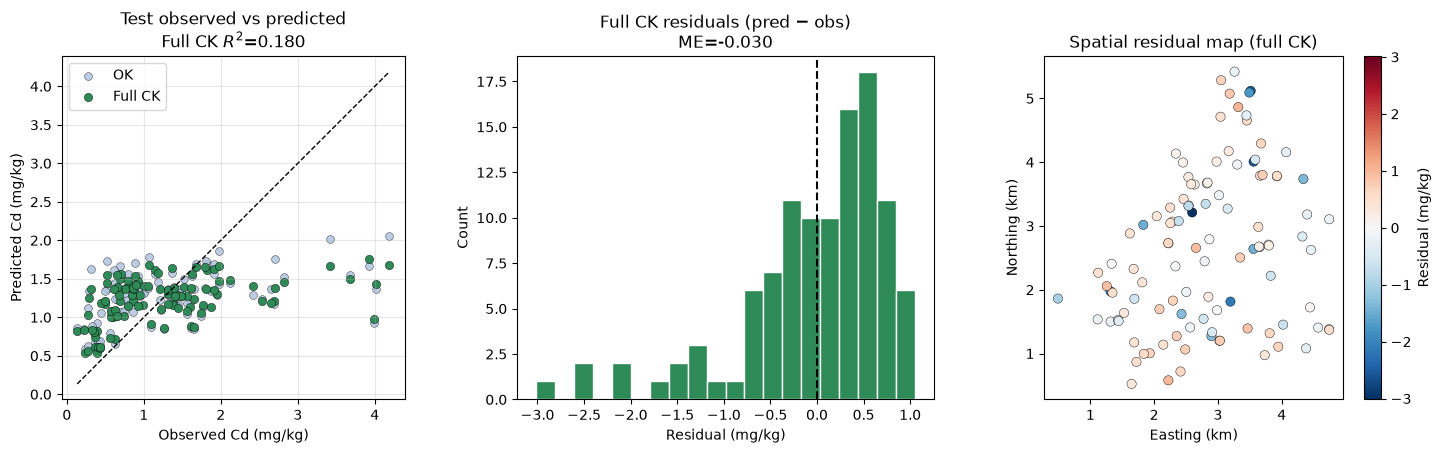

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

lo = min(z_test["Cd"].min(), full_hat.min(), ok_hat.min())
hi = max(z_test["Cd"].max(), full_hat.max(), ok_hat.max())
axes[0].scatter(z_test["Cd"], ok_hat, c="lightsteelblue", edgecolors="k",
                linewidths=0.3, s=32, label="OK", alpha=0.85)
axes[0].scatter(z_test["Cd"], full_hat, c="seagreen", edgecolors="k",
                linewidths=0.3, s=36, label="Full CK")
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel("Observed Cd (mg/kg)"); axes[0].set_ylabel("Predicted Cd (mg/kg)")
axes[0].set_title(f"Test observed vs predicted\nFull CK $R^2$={full_row['R2']:.3f}")
axes[0].set_aspect("equal", adjustable="box"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(resid_full, bins=20, color="seagreen", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title(f"Full CK residuals (pred − obs)\nME={full_row['ME']:+.3f}")
axes[1].set_xlabel("Residual (mg/kg)"); axes[1].set_ylabel("Count")

vmax = np.max(np.abs(resid_full))
sc = axes[2].scatter(df_test[x_col], df_test[y_col], c=resid_full, cmap="RdBu_r",
                     s=45, edgecolors="k", linewidths=0.3, vmin=-vmax, vmax=vmax)
plt.colorbar(sc, ax=axes[2], label="Residual (mg/kg)")
axes[2].set_aspect("equal")
axes[2].set_title("Spatial residual map (full CK)")
axes[2].set_xlabel("Easting (km)"); axes[2].set_ylabel("Northing (km)")

plt.tight_layout(); plt.show()


***
## 12. Colocated Cokriging

Markov-model colocated cokriging uses every training **Cd** sample plus Zn and Ni **only at the prediction location**. That is the natural estimator when the secondaries are exhaustive (known on a grid or at every test site).

`ColocatedCokriging` implements MM1:

$$
C_{\mathrm{Cd},k}(h)=\frac{C_{\mathrm{Cd},k}(0)}{C_{\mathrm{Cd}}(0)}\,C_{\mathrm{Cd}}(h), \qquad k\in\{\mathrm{Zn},\mathrm{Ni}\}.
$$

On the test set we pass the **observed** Zn and Ni (exhaustive-secondary validation). On the grid we will first map Zn and Ni by ordinary kriging.


In [17]:
cck = ColocatedCokriging(
    primary_var=vgs[0],
    secondary_vars=[vgs[1], vgs[2]],
    cross_vars=[cross[(0, 1)], cross[(0, 2)]],
    secondary_cross_vars={(0, 1): cross[(1, 2)]},
    mm1=True,
    use_gpu=USE_GPU,
).fit(
    coords_train, z_train["Cd"],
    secondary_means=[float(z_train["Zn"].mean()), float(z_train["Ni"].mean())],
)

print("Estimator               : Colocated cokriging (MM1)")
print(f"Primary n               : {len(z_train['Cd'])}")
print("Secondaries at x0       : Zn, Ni")
print(f"C_Cd(0)                 : {cck.C00:.4f}")
print(f"C_Cd,Zn(0), C_Cd,Ni(0)  : {cck.C0k[0]:.4f}, {cck.C0k[1]:.4f}")
rho_zn = cck.C0k[0] / np.sqrt(cck.C00 * cck.Ckk[0])
rho_ni = cck.C0k[1] / np.sqrt(cck.C00 * cck.Ckk[1])
print(f"MM1 lag-0 correlation   : Cd–Zn = {rho_zn:.3f},  Cd–Ni = {rho_ni:.3f}")


Estimator               : Colocated cokriging (MM1)
Primary n               : 251
Secondaries at x0       : Zn, Ni
C_Cd(0)                 : 0.7061
C_Cd,Zn(0), C_Cd,Ni(0)  : 16.9100, 4.0016
MM1 lag-0 correlation   : Cd–Zn = 0.596,  Cd–Ni = 0.524


***
## 13. Validate Colocated Cokriging

Because Zn and Ni are observed at the test sites, colocated cokriging is allowed to use them. That extra information is why colocated CK should beat OK here — it is not a like-for-like comparison with full CK, which never sees test-set secondaries.


In [18]:
Y_test = np.column_stack([z_test["Zn"], z_test["Ni"]])
col_hat, col_se = cck.predict(coords_test, Y_test, return_variance=True)
col_row = metrics_row(
    "Colocated CK (obs. Zn, Ni at x0)", z_test["Cd"], col_hat, col_se,
    extra={"n_primary": len(z_train["Cd"]), "n_Zn": "at x0", "n_Ni": "at x0"},
)

print("Colocated cokriging — test-set validation (observed secondaries)")
print("=" * 60)
for k, v in col_row.items():
    print(f"  {k:12s}: {v}")

resid_col = col_hat - z_test["Cd"]


Colocated cokriging — test-set validation (observed secondaries)
  method      : Colocated CK (obs. Zn, Ni at x0)
  n_test      : 108
  RMSE        : 0.6895
  MAE         : 0.4975
  ME          : -0.0369
  R2          : 0.3976
  mean_SE     : 0.6278
  n_primary   : 251
  n_Zn        : at x0
  n_Ni        : at x0


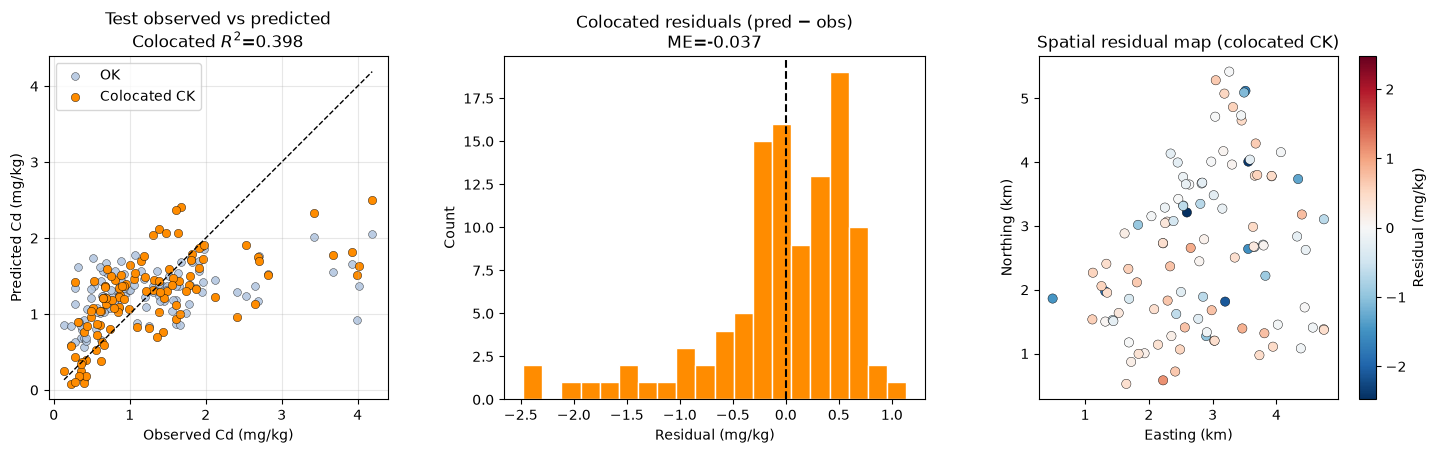

Colocated standardized residual mean: -0.059   std: 1.096  (ideal: 0, 1)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

axes[0].scatter(z_test["Cd"], ok_hat, c="lightsteelblue", edgecolors="k",
                linewidths=0.3, s=32, label="OK", alpha=0.85)
axes[0].scatter(z_test["Cd"], col_hat, c="darkorange", edgecolors="k",
                linewidths=0.3, s=36, label="Colocated CK")
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel("Observed Cd (mg/kg)"); axes[0].set_ylabel("Predicted Cd (mg/kg)")
axes[0].set_title(f"Test observed vs predicted\nColocated $R^2$={col_row['R2']:.3f}")
axes[0].set_aspect("equal", adjustable="box"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(resid_col, bins=20, color="darkorange", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title(f"Colocated residuals (pred − obs)\nME={col_row['ME']:+.3f}")
axes[1].set_xlabel("Residual (mg/kg)"); axes[1].set_ylabel("Count")

vmax = np.max(np.abs(resid_col))
sc = axes[2].scatter(df_test[x_col], df_test[y_col], c=resid_col, cmap="RdBu_r",
                     s=45, edgecolors="k", linewidths=0.3, vmin=-vmax, vmax=vmax)
plt.colorbar(sc, ax=axes[2], label="Residual (mg/kg)")
axes[2].set_aspect("equal")
axes[2].set_title("Spatial residual map (colocated CK)")
axes[2].set_xlabel("Easting (km)"); axes[2].set_ylabel("Northing (km)")

plt.tight_layout(); plt.show()

std_resid = resid_col / np.clip(col_se, 1e-8, None)
print(f"Colocated standardized residual mean: {std_resid.mean():+.3f}   "
      f"std: {std_resid.std():.3f}  (ideal: 0, 1)")


***
## 14. Heterotopic Sampling

The Jura survey is **isotopic**: Cd, Zn, and Ni were all measured at every borehole. That hides cokriging’s usual advantage. We now mimic a cheaper secondary network: keep Zn and Ni at **all** training sites, but retain Cd at only **40%** of the training sites (stratified by Landuse). Full cokriging may then use the dense Zn/Ni to help interpolate the sparse Cd.

This is the design Goovaerts used to motivate cokriging of Jura cadmium.


In [20]:
sss_h = StratifiedShuffleSplit(n_splits=1, test_size=0.60, random_state=7)
cd_keep_idx, _ = next(sss_h.split(df_train, df_train[strata_col]))

coords_cd_sparse = coords_train[cd_keep_idx]
cd_sparse = z_train["Cd"][cd_keep_idx]

print(f"Sparse Cd training locations : {len(cd_sparse)} / {len(z_train['Cd'])} "
      f"({100*len(cd_sparse)/len(z_train['Cd']):.0f}%)")
print(f"Zn, Ni training locations    : {len(z_train['Zn'])} (100% of train)")

# Variograms / LMC from the colocated sparse subset (CrossVariogram needs colocated samples)
vgs_h, cross_h, lmc_h = fit_lmc(
    coords_cd_sparse,
    [cd_sparse, z_train["Zn"][cd_keep_idx], z_train["Ni"][cd_keep_idx]],
    names=["Cd", "Zn", "Ni"],
    model=lmc_model,
    n_lags=12,
    shared_range=True,
)
print(f"Heterotopic LMC valid : {lmc_h['lmc_check']['valid']}   "
      f"range = {lmc_h['range']:.3f} km")

ok_h = OrdinaryKriging(vgs_h[0], use_gpu=USE_GPU).fit(coords_cd_sparse, cd_sparse)
ok_h_hat, ok_h_se = ok_h.predict(coords_test, return_variance=True)

ck_h = MultivariateCokriging(vgs_h, cross_h, use_gpu=USE_GPU).fit(
    [coords_cd_sparse, coords_train, coords_train],
    [cd_sparse, z_train["Zn"], z_train["Ni"]],
)
ck_h_hat, ck_h_se = ck_h.predict(coords_test, return_variance=True)

cck_h = ColocatedCokriging(
    vgs_h[0], [vgs_h[1], vgs_h[2]],
    [cross_h[(0, 1)], cross_h[(0, 2)]],
    secondary_cross_vars={(0, 1): cross_h[(1, 2)]},
    mm1=True,
    use_gpu=USE_GPU,
).fit(
    coords_cd_sparse, cd_sparse,
    secondary_means=[float(z_train["Zn"].mean()), float(z_train["Ni"].mean())],
)
col_h_hat, col_h_se = cck_h.predict(coords_test, Y_test, return_variance=True)

hetero_table = pd.DataFrame([
    metrics_row("OK (sparse Cd)", z_test["Cd"], ok_h_hat, ok_h_se,
                extra={"n_Cd": len(cd_sparse)}),
    metrics_row("Full CK (sparse Cd + dense Zn,Ni)", z_test["Cd"], ck_h_hat, ck_h_se,
                extra={"n_Cd": len(cd_sparse)}),
    metrics_row("Colocated CK (sparse Cd + Zn,Ni at x0)", z_test["Cd"], col_h_hat, col_h_se,
                extra={"n_Cd": len(cd_sparse)}),
])
print("\nHeterotopic experiment — same test set, 40% of training Cd")
hetero_table


Sparse Cd training locations : 100 / 251 (40%)
Zn, Ni training locations    : 251 (100% of train)
Heterotopic LMC valid : True   range = 1.342 km



Heterotopic experiment — same test set, 40% of training Cd


,method,n_test,RMSE,MAE,ME,R2,mean_SE,n_Cd
0,OK (sparse Cd),108,0.8412,0.6504,0.1224,0.1032,0.8206,100
1,"Full CK (sparse Cd + dense Zn,Ni)",108,0.8324,0.6379,0.0556,0.1220,0.7915,100
2,"Colocated CK (sparse Cd + Zn,Ni at x0)",108,0.6874,0.4990,0.0715,0.4012,0.6343,100


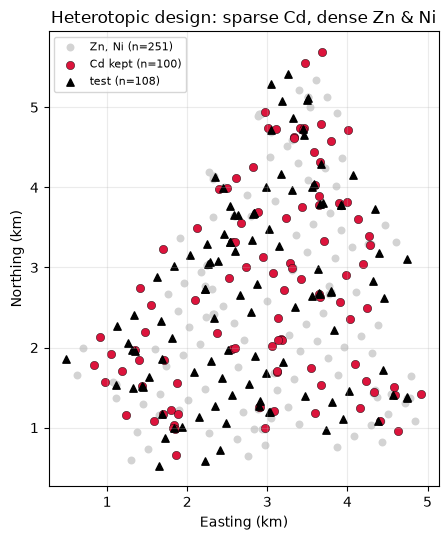

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(coords_train[:, 0], coords_train[:, 1], c="lightgrey", s=22,
           label=f"Zn, Ni (n={len(coords_train)})")
ax.scatter(coords_cd_sparse[:, 0], coords_cd_sparse[:, 1], c="crimson", s=36,
           edgecolors="k", linewidths=0.3, label=f"Cd kept (n={len(cd_sparse)})")
ax.scatter(coords_test[:, 0], coords_test[:, 1], c="k", s=28, marker="^",
           label=f"test (n={len(coords_test)})")
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title("Heterotopic design: sparse Cd, dense Zn & Ni")
ax.legend(frameon=True, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


***
## 15. Compare Methods

Isotopic training uses every metal at the same 70% of sites. Heterotopic training withholds 60% of those Cd values. Colocated CK always sees Zn and Ni at the test location.


Isotopic training (all metals at every training site)
                          method   RMSE    MAE      ME     R2  mean_SE
           Ordinary kriging (Cd) 0.7970 0.5879  0.0043 0.1950   0.7872
       Full cokriging (Cd+Zn+Ni) 0.8043 0.5961 -0.0298 0.1802   0.7777
Colocated CK (obs. Zn, Ni at x0) 0.6895 0.4975 -0.0369 0.3976   0.6278

Heterotopic training (40% of training Cd)
                                method   RMSE    MAE     ME     R2  mean_SE
                        OK (sparse Cd) 0.8412 0.6504 0.1224 0.1032   0.8206
     Full CK (sparse Cd + dense Zn,Ni) 0.8324 0.6379 0.0556 0.1220   0.7915
Colocated CK (sparse Cd + Zn,Ni at x0) 0.6874 0.4990 0.0715 0.4012   0.6343


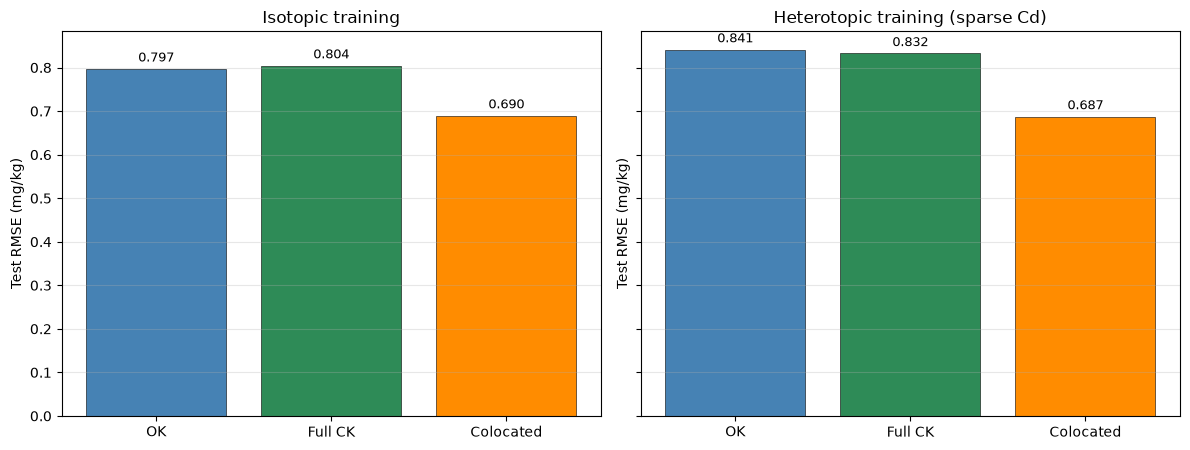

In [22]:
iso_table = pd.DataFrame([ok_row, full_row, col_row])
print("Isotopic training (all metals at every training site)")
display_cols = ["method", "RMSE", "MAE", "ME", "R2", "mean_SE"]
print(iso_table[display_cols].to_string(index=False))

print("\nHeterotopic training (40% of training Cd)")
print(hetero_table[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, table, title in zip(
    axes,
    [iso_table, hetero_table],
    ["Isotopic training", "Heterotopic training (sparse Cd)"],
):
    ax.bar(np.arange(len(table)), table["RMSE"], color=["steelblue", "seagreen", "darkorange"],
           edgecolor="k", linewidth=0.4)
    ax.set_xticks(np.arange(len(table)))
    ax.set_xticklabels(["OK", "Full CK", "Colocated"], rotation=0)
    ax.set_ylabel("Test RMSE (mg/kg)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(table["RMSE"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


***
## 16. Predict Cd on the Jura Grid

We map with the **isotopic** models fitted on the full training set.

* **Full cokriging** uses training Cd, Zn, and Ni only — no grid covariates.
* **Colocated cokriging** needs Zn and Ni at every grid node. We ordinary-krige those two metals from the training samples, then feed the maps into `ColocatedCokriging`.
* Ordinary kriging of Cd is kept as a univariate baseline map.


In [23]:
print("Ordinary-kriging Zn and Ni onto the grid (colocated secondaries)...")
ok_zn = OrdinaryKriging(vgs[1], use_gpu=USE_GPU).fit(coords_train, z_train["Zn"])
ok_ni = OrdinaryKriging(vgs[2], use_gpu=USE_GPU).fit(coords_train, z_train["Ni"])
zn_grid, zn_se = ok_zn.predict(grid_coords, return_variance=True)
ni_grid, ni_se = ok_ni.predict(grid_coords, return_variance=True)
Y_grid = np.column_stack([zn_grid, ni_grid])
print(f"  Zn grid  min/mean/max : {zn_grid.min():.1f} / {zn_grid.mean():.1f} / {zn_grid.max():.1f}")
print(f"  Ni grid  min/mean/max : {ni_grid.min():.1f} / {ni_grid.mean():.1f} / {ni_grid.max():.1f}")

print("Predicting Cd...")
ok_grid, ok_grid_se = ok.predict(grid_coords, return_variance=True)
full_grid, full_grid_se = ck_full.predict(grid_coords, return_variance=True)
col_grid, col_grid_se = cck.predict(grid_coords, Y_grid, return_variance=True)

grid_out = grid.copy()
grid_out["Zn_pred"] = zn_grid
grid_out["Ni_pred"] = ni_grid
grid_out["Cd_OK"] = ok_grid
grid_out["Cd_OK_se"] = ok_grid_se
grid_out["Cd_fullCK"] = full_grid
grid_out["Cd_fullCK_se"] = full_grid_se
grid_out["Cd_colCK"] = col_grid
grid_out["Cd_colCK_se"] = col_grid_se

print(f"\nGrid predictions: n = {len(grid_out)}")
for lab, p, s in [
    ("OK      ", ok_grid, ok_grid_se),
    ("Full CK ", full_grid, full_grid_se),
    ("Coloc.  ", col_grid, col_grid_se),
]:
    print(f"  {lab} Cd min/mean/max : {p.min():.3f} / {p.mean():.3f} / {p.max():.3f}   "
          f"SE mean = {s.mean():.3f}")
grid_out[[x_col, y_col, "Cd_OK", "Cd_fullCK", "Cd_colCK", "Cd_colCK_se"]].head()


Ordinary-kriging Zn and Ni onto the grid (colocated secondaries)...


  Zn grid  min/mean/max : 36.2 / 77.1 / 140.0
  Ni grid  min/mean/max : 6.0 / 21.0 / 38.0
Predicting Cd...



Grid predictions: n = 5957
  OK       Cd min/mean/max : 0.559 / 1.324 / 2.032   SE mean = 0.792
  Full CK  Cd min/mean/max : 0.521 / 1.322 / 1.894   SE mean = 0.782
  Coloc.   Cd min/mean/max : 0.136 / 1.336 / 2.226   SE mean = 0.631


,Xloc,Yloc,Cd_OK,Cd_fullCK,Cd_colCK,Cd_colCK_se
0,0.30,1.70,1.230870,1.281923,1.176199,0.650238
1,0.35,1.70,1.235856,1.281203,1.173523,0.648511
2,0.35,1.75,1.242488,1.312038,1.203602,0.648396
3,0.40,1.70,1.240399,1.278257,1.168796,0.646628
4,0.40,1.75,1.247656,1.311950,1.201602,0.646518


***
## 17. Map Predicted Concentration and Error

The colocated map should look more like the Zn/Ni pattern than the OK map does, because each grid node is pulled toward the colocated secondaries. Full cokriging on an isotopic network stays close to OK. Kriging standard error shrinks where samples (and, for colocated CK, informative secondaries) are dense.


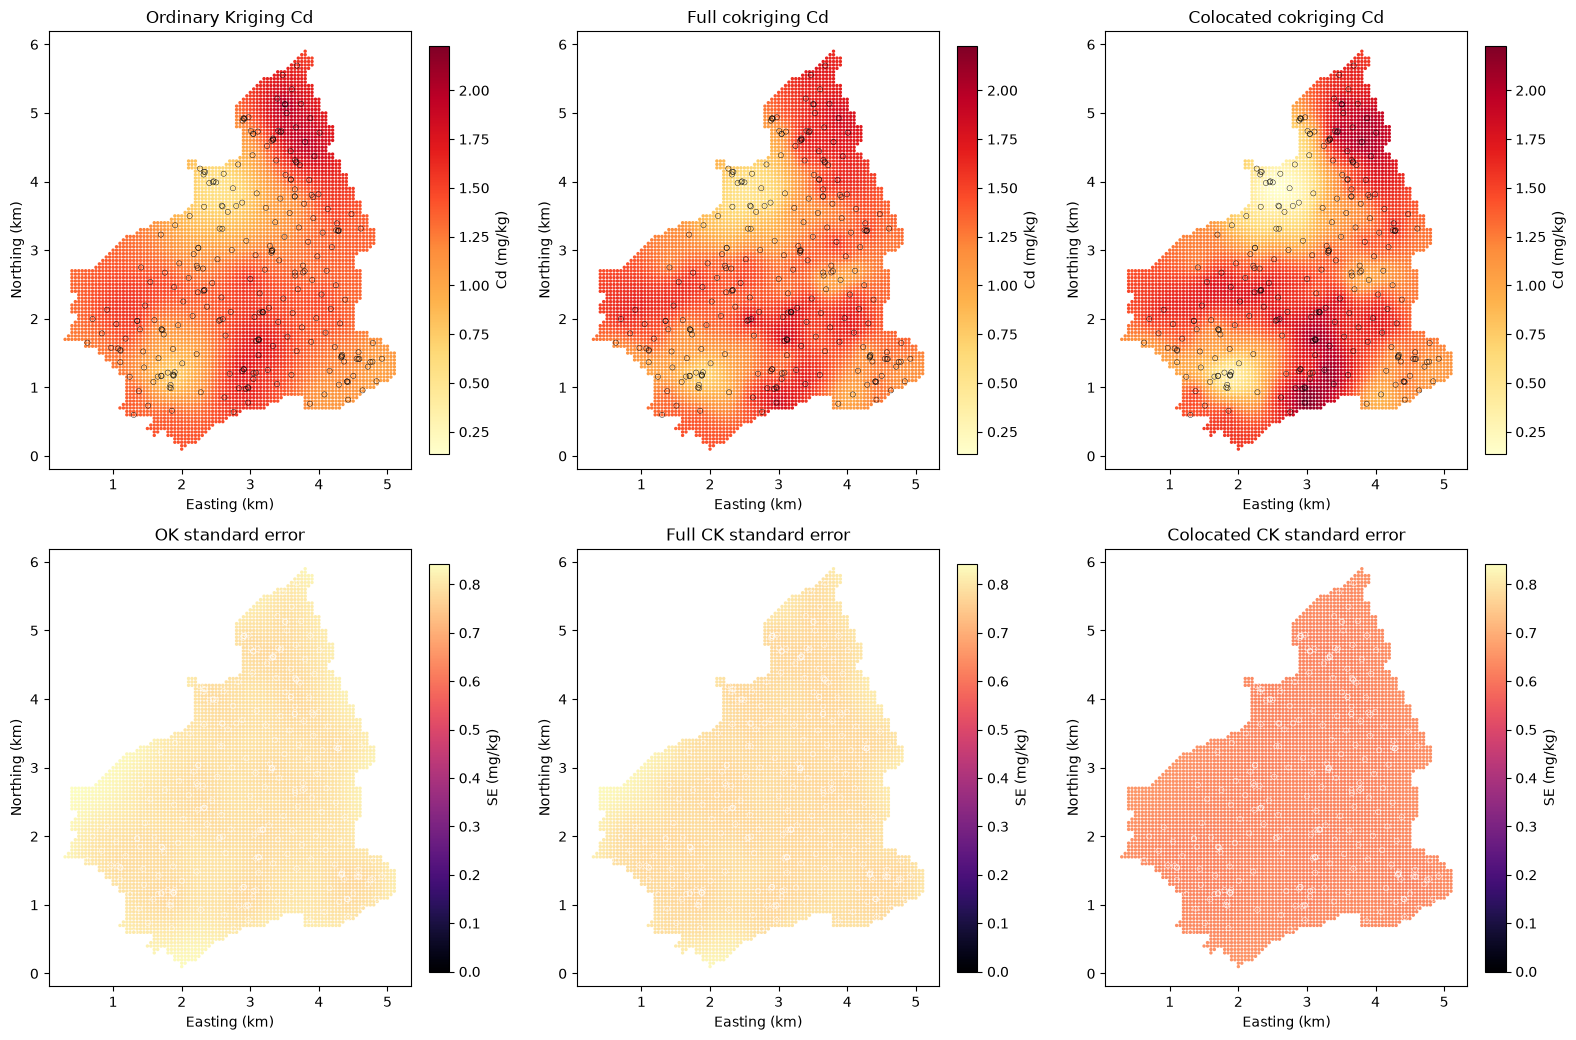

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10.5))

pred_panels = [
    (axes[0, 0], ok_grid, "Ordinary Kriging Cd", "YlOrRd", "Cd (mg/kg)"),
    (axes[0, 1], full_grid, "Full cokriging Cd", "YlOrRd", "Cd (mg/kg)"),
    (axes[0, 2], col_grid, "Colocated cokriging Cd", "YlOrRd", "Cd (mg/kg)"),
    (axes[1, 0], ok_grid_se, "OK standard error", "magma", "SE (mg/kg)"),
    (axes[1, 1], full_grid_se, "Full CK standard error", "magma", "SE (mg/kg)"),
    (axes[1, 2], col_grid_se, "Colocated CK standard error", "magma", "SE (mg/kg)"),
]
vmin_cd = min(ok_grid.min(), full_grid.min(), col_grid.min())
vmax_cd = max(ok_grid.max(), full_grid.max(), col_grid.max())
vmin_se = 0.0
vmax_se = max(ok_grid_se.max(), full_grid_se.max(), col_grid_se.max())

for i, (ax, vals, title, cmap, clab) in enumerate(pred_panels):
    if i < 3:
        kw = dict(vmin=vmin_cd, vmax=vmax_cd, cmap=cmap)
        edge = "k"
    else:
        kw = dict(vmin=vmin_se, vmax=vmax_se, cmap=cmap)
        edge = "w"
    sc = ax.scatter(grid_out[x_col], grid_out[y_col], c=vals, s=8, marker=".", **kw)
    ax.scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors=edge,
               s=14, linewidths=0.3, label="train")
    plt.colorbar(sc, ax=ax, label=clab, fraction=0.046, pad=0.04)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")

plt.tight_layout(); plt.show()


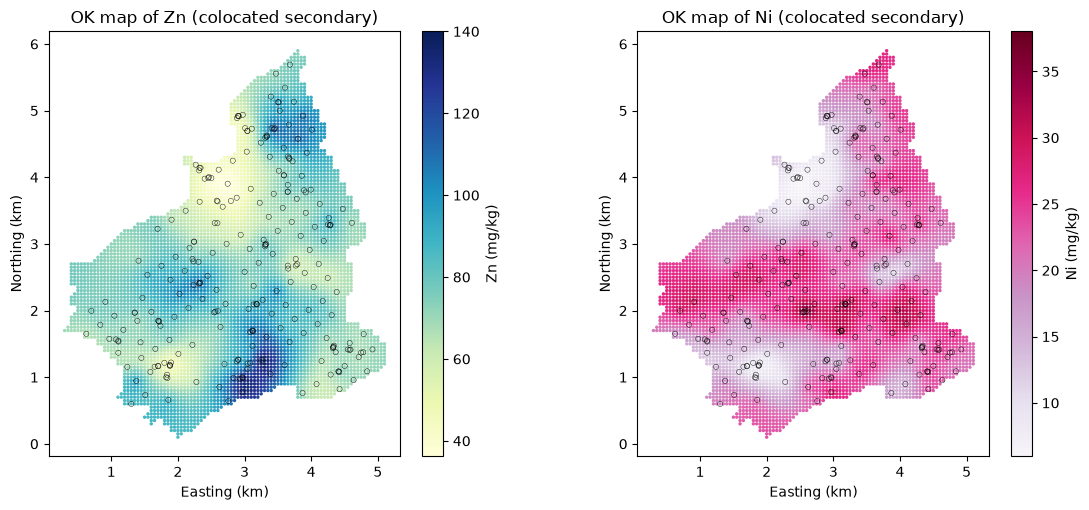

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
sc0 = axes[0].scatter(grid_out[x_col], grid_out[y_col], c=zn_grid,
                      cmap="YlGnBu", s=8, marker=".")
axes[0].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
                s=14, linewidths=0.3)
plt.colorbar(sc0, ax=axes[0], label="Zn (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_aspect("equal")
axes[0].set_title("OK map of Zn (colocated secondary)")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")

sc1 = axes[1].scatter(grid_out[x_col], grid_out[y_col], c=ni_grid,
                      cmap="PuRd", s=8, marker=".")
axes[1].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
                s=14, linewidths=0.3)
plt.colorbar(sc1, ax=axes[1], label="Ni (mg/kg)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_title("OK map of Ni (colocated secondary)")
axes[1].set_xlabel("Easting (km)"); axes[1].set_ylabel("Northing (km)")
plt.tight_layout(); plt.show()


***
## 18. Probability Maps of Exceedance

Under the Gaussian colocated-cokriging model (the most accurate of the three on this split),

$$
P(\text{Cd}(\mathbf{x}_0) > z_c)
= 1 - \Phi\!\left(\frac{z_c - \hat{Z}_{\text{col}}(\mathbf{x}_0)}{\sigma_{\text{col}}(\mathbf{x}_0)}\right).
$$

Cutoffs: **0.10, 0.25, 0.50, 0.75, and 1.00 mg/kg** (same as Tutorials 03–05).


In [26]:
cutoffs = [0.10, 0.25, 0.50, 0.75, 1.00]   # mg/kg
se_safe = np.clip(col_grid_se, 1e-8, None)

prob_cols = []
for zc in cutoffs:
    col = f"P_Cd_gt_{zc:.2f}".replace(".", "p")
    grid_out[col] = 1.0 - norm.cdf((zc - col_grid) / se_safe)
    prob_cols.append(col)
    print(f"P(Cd > {zc:4.2f})  mean={grid_out[col].mean():.3f}  "
          f"min={grid_out[col].min():.3f}  max={grid_out[col].max():.3f}")

emp = {zc: float(np.mean(z_train["Cd"] > zc)) for zc in cutoffs}
print("\nEmpirical P(Cd > zc) on training samples:")
for zc, p in emp.items():
    print(f"  {zc:4.2f} mg/kg : {p:.3f}")


P(Cd > 0.10)  mean=0.948  min=0.523  max=1.000
P(Cd > 0.25)  mean=0.924  min=0.427  max=0.999
P(Cd > 0.50)  mean=0.868  min=0.280  max=0.997
P(Cd > 0.75)  mean=0.786  min=0.162  max=0.990
P(Cd > 1.00)  mean=0.679  min=0.083  max=0.974

Empirical P(Cd > zc) on training samples:
  0.10 mg/kg : 1.000
  0.25 mg/kg : 0.976
  0.50 mg/kg : 0.873
  0.75 mg/kg : 0.701
  1.00 mg/kg : 0.546


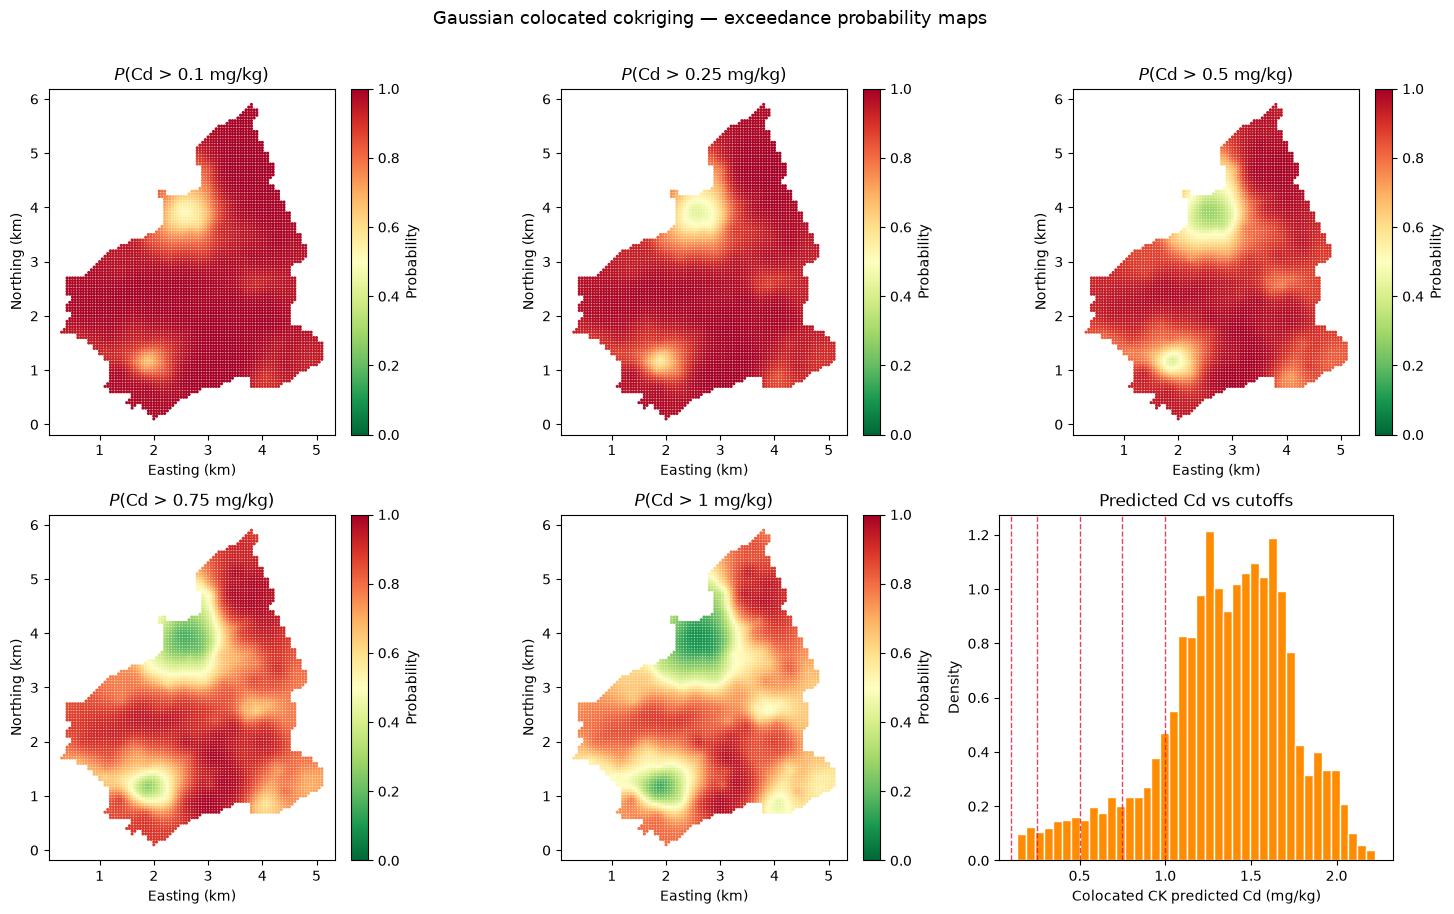

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, zc, col in zip(axes, cutoffs, prob_cols):
    sc = ax.scatter(grid_out[x_col], grid_out[y_col], c=grid_out[col],
                    cmap="RdYlGn_r", s=6, marker=".", vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Probability")
    ax.set_aspect("equal")
    ax.set_title(f"$P$(Cd > {zc:g} mg/kg)")
    ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")

axes[5].hist(col_grid, bins=40, color="darkorange", edgecolor="white", density=True)
for zc in cutoffs:
    axes[5].axvline(zc, color="crimson", ls="--", lw=1, alpha=0.8)
axes[5].set_title("Predicted Cd vs cutoffs")
axes[5].set_xlabel("Colocated CK predicted Cd (mg/kg)"); axes[5].set_ylabel("Density")

plt.suptitle("Gaussian colocated cokriging — exceedance probability maps", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


In [28]:
se_test_safe = np.clip(col_se, 1e-8, None)
rows = []
for zc in cutoffs:
    p_hat = 1.0 - norm.cdf((zc - col_hat) / se_test_safe)
    y_ind = (z_test["Cd"] > zc).astype(float)
    brier = float(np.mean((p_hat - y_ind) ** 2))
    rows.append({
        "cutoff_mgkg": zc,
        "empirical_rate_test": round(float(y_ind.mean()), 3),
        "mean_predicted_P": round(float(p_hat.mean()), 3),
        "Brier": round(brier, 4),
    })
pd.DataFrame(rows).set_index("cutoff_mgkg")


,empirical_rate_test,mean_predicted_P,Brier
cutoff_mgkg,,,
0.10,1.000,0.910,0.0252
0.25,0.972,0.878,0.0420
0.50,0.824,0.809,0.0734
0.75,0.639,0.719,0.1419
1.00,0.509,0.611,0.1736


***
## 19. CPU vs GPU Cokriging Timing

Section 4.1 showed how to *select* a backend. Here we measure how long **full ordinary cokriging** (`MultivariateCokriging`) takes on **CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`) — first on the Jura samples ($n=359$ of Cd, Zn, and Ni) predicting the Jura grid, then on prefixes of a **simulated Jura-like** bivariate survey with $n=6{,}000$.

The simulated survey places $6{,}000$ points uniformly in the Jura bounding box and builds two correlated fields (Cd-like primary, Zn-like secondary) from shared plus independent spatial factors, so the lag-0 correlation is in the same ballpark as Jura Cd–Zn. Full cokriging of three metals at $n=6{,}000$ would be a $18{,}000\times 18{,}000$ system; the scaling jobs therefore use **two** variables (primary + one secondary) so the LU factor is $(2n+2)\times(2n+2)$ and can grow past $5{,}000$ on a workstation GPU.

The GPU-accelerated steps are the coregionalization matrix, its LU factor (cached at `fit()`), and the multi-RHS solve at `predict()`. LMC fitting is done once per dataset and is **not** included in the cokriging times.

Each timing is the **median** of three `MultivariateCokriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup. If CuPy cannot run a kernel here, the GPU column is skipped.


GPU usable : True
Repeats    : 3  (median wall time of CK fit + predict)
Jura       : 359 samples of Cd, Zn, Ni → 5957 grid nodes
Simulated  : 6000 Cd/Zn-like points on the Jura domain  (corr = 0.45)
Sim n_pred : 200 locations drawn from each prefix

        dataset  n_train  n_pred  n_var  CPU (ms)  GPU (ms) speedup  match
Jura (Cd+Zn+Ni)      359    5957      3     438.3     100.1   4.38×   True
  Sim Jura-like      500     200      2      94.0      24.6   3.82×   True
  Sim Jura-like     1000     200      2     259.5      62.5   4.15×   True
  Sim Jura-like     2000     200      2     959.1     186.5   5.14×   True
  Sim Jura-like     4000     200      2    4836.3    1078.5   4.48×   True
  Sim Jura-like     6000     200      2   11123.5    3252.8   3.42×   True


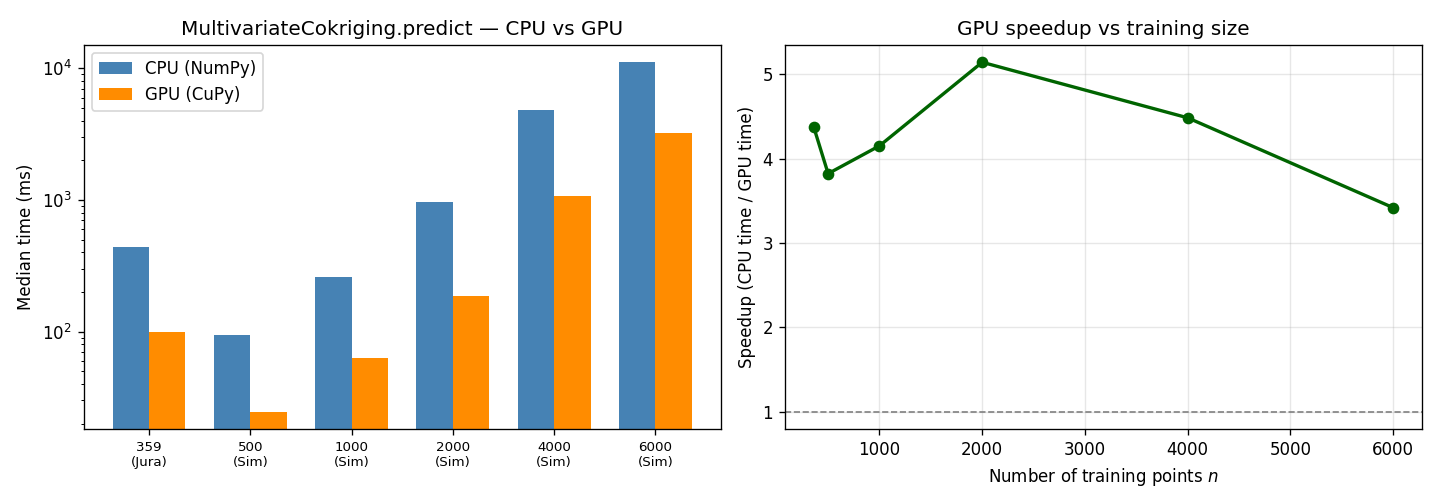

In [28]:
import time

N_LAGS = 12
N_REPEATS = 3
N_PRED_SIM = 200
SIM_N = 6000
SIM_SIZES = [500, 1000, 2000, 4000, 6000]


def _simulate_jura_like(n=SIM_N, seed=42):
    """Cd/Zn-like correlated fields on a Jura-sized domain (km)."""
    rng = np.random.default_rng(seed)
    xmin, xmax = 0.05, 4.95
    ymin, ymax = 0.05, 5.85
    xy = rng.uniform([xmin, ymin], [xmax, ymax], size=(n, 2))

    def field(n_centers=48, length=1.4):
        centers = rng.uniform([xmin, ymin], [xmax, ymax], size=(n_centers, 2))
        amps = rng.normal(size=n_centers)
        d2 = ((xy[:, None, :] - centers) ** 2).sum(-1)
        f = np.exp(-d2 / (2.0 * length ** 2)) @ amps
        f = (f - f.mean()) / (f.std() + 1e-12)
        return f

    shared, f1, f2 = field(), field(), field()
    z1 = 0.72 * shared + 0.69 * f1
    z2 = 0.72 * shared + 0.69 * f2
    z1 = 1.31 + 0.90 * (z1 - z1.mean()) / z1.std()
    z2 = 75.1 + 31.0 * (z2 - z2.mean()) / z2.std()
    return xy, z1, z2


def _time_ck(coords_list, values_list, xy_pred, vgs, cross, use_gpu,
             repeats=N_REPEATS, warmup=True):
    """Median wall time of MultivariateCokriging.fit + predict(return_variance=True)."""
    if warmup:
        k = min(40, min(len(c) for c in coords_list))
        k_pr = min(40, len(xy_pred))
        MultivariateCokriging(vgs, cross, use_gpu=use_gpu).fit(
            [c[:k] for c in coords_list],
            [v[:k] for v in values_list],
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ck = MultivariateCokriging(vgs, cross, use_gpu=use_gpu).fit(
            coords_list, values_list
        )
        last = ck.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


sim_xy, sim_z1, sim_z2 = _simulate_jura_like()
rng = np.random.default_rng(42)

jobs = [{
    "dataset": "Jura (Cd+Zn+Ni)",
    "n_var": 3,
    "coords_list": [coords, coords, coords],
    "values_list": [df["Cd"].to_numpy(dtype=float),
                    df["Zn"].to_numpy(dtype=float),
                    df["Ni"].to_numpy(dtype=float)],
    "xy_pred": np.asarray(grid_coords, dtype=float),
}]
for n in SIM_SIZES:
    n_pred = min(N_PRED_SIM, n)
    pred_idx = rng.choice(n, size=n_pred, replace=False)
    jobs.append({
        "dataset": "Sim Jura-like",
        "n_var": 2,
        "coords_list": [sim_xy[:n], sim_xy[:n]],
        "values_list": [sim_z1[:n], sim_z2[:n]],
        "xy_pred": sim_xy[pred_idx],
    })

print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of CK fit + predict)")
print(f"Jura       : {len(coords)} samples of Cd, Zn, Ni → {len(grid_coords)} grid nodes")
print(f"Simulated  : {SIM_N} Cd/Zn-like points on the Jura domain  (corr = {np.corrcoef(sim_z1, sim_z2)[0, 1]:.2f})")
print(f"Sim n_pred : {N_PRED_SIM} locations drawn from each prefix")
print()

rows = []
for job in jobs:
    cl, vl, xy_pr = job["coords_list"], job["values_list"], job["xy_pred"]
    names = ["Cd", "Zn", "Ni"][:job["n_var"]] if job["n_var"] == 3 else ["Z1", "Z2"]
    vgs, cross, _ = fit_lmc(
        cl[0], vl, names=names, model="spherical", n_lags=N_LAGS, use_gpu=False,
    )
    cpu_t, pred_cpu = _time_ck(cl, vl, xy_pr, vgs, cross, use_gpu=False)
    row = {
        "dataset": job["dataset"],
        "n_train": len(cl[0]),
        "n_pred": len(xy_pr),
        "n_var": job["n_var"],
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_ck(cl, vl, xy_pr, vgs, cross, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-3, atol=1e-3, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-3, atol=1e-3, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "n_var", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [
    f"{int(n)}\n({ds.split()[0]})"
    for n, ds in zip(n_vals, df_bench["dataset"])
]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("MultivariateCokriging.predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). Jura still benefits from the GPU because we predict 5{,}957 grid nodes even though $n=359$ is small (3-variable system $\approx 1{,}080$). On the simulated survey the LU factor of the $(2n+2)$ cokriging matrix dominates: GPU speedup is about $4$–$5\times$ through $n=4{,}000$, then a little less at $n=6{,}000$ as host–device copies of the large coregionalization matrix catch up. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 20. Summary and Conclusions

This tutorial walked through a complete **cokriging** workflow for Jura cadmium, using zinc and nickel as secondary variables.

### What we did

1. Split 359 samples **70 / 30** with **stratified random sampling by Landuse** (same seed as Tutorials 02–04).
2. Confirmed moderate Cd–Zn and Cd–Ni correlations and mapped all three metals.
3. Selected a Cd auto-variogram by AIC and fitted a **linear model of coregionalization** for (Cd, Zn, Ni).
4. Fitted **ordinary kriging**, **full ordinary cokriging**, and **MM1 colocated cokriging** with `use_gpu=USE_GPU`.
5. Validated on the held-out test set (RMSE, MAE, mean error, $R^2$).
6. Repeated the comparison with **heterotopic** (undersampled) Cd — the setting where cokriging is designed to win.
7. Mapped Cd, kriging standard error, and Gaussian exceedance probabilities on `jura_grid.csv`.
8. Timed `MultivariateCokriging.predict` on **CPU vs GPU** for Jura Cd–Zn–Ni and a simulated Jura-like survey with $n=6{,}000$.

### Practical takeaways

- **Full cokriging** on an isotopic network is often close to ordinary kriging. The extra secondary samples at the *same* sites add little once Cd is already observed there.
- **Cokriging pays off under heterotopy**: sparse Cd plus dense Zn/Ni. That is the usual environmental design (few lab assays, many cheaper field or remote-sensing covariates).
- **Colocated cokriging** is the right tool when the secondary is exhaustive (known at every $\mathbf{x}_0$). The MM1 screening model keeps the system almost as small as univariate OK.
- An LMC must be **positive semi-definite**. Check the eigenvalues of $\mathbf{B}_0$ and $\mathbf{B}_1$ before kriging.
- Mapping with colocated CK requires a secondary map. Interpolating Zn and Ni by OK, then cokriging Cd, is the standard two-step workflow when the grid has no covariates.
- Gaussian $P(\text{Cd}>z_c)$ is an approximation for skewed concentrations; indicator kriging is the nonparametric alternative.
- A GPU pays off for full cokriging when $n$ is large *or* you predict a dense grid. The system is roughly $p n$ on an isotopic network, so memory and the LU factor grow faster than univariate OK.

### Next steps

- Compare test RMSE with Tutorials 02 (SK), 03 (OK), and 04 (UK) on this same split
- Regression kriging: use Landuse / Rock as external drift instead of (or with) Zn and Ni
- Indicator cokriging of $I(\text{Cd}>z_c)$ using indicator transforms of Zn and Ni


***
## 21. Resources

### Textbooks

| Reference | Notes |
|-----------|-------|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Jura Cd–Ni–Zn cokriging; LMC |
| Wackernagel, H. (2003). *Multivariate Geostatistics* (3rd ed.). Springer. | Coregionalization, cokriging systems |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Multivariate covariance models |
| Isaaks, E.H. & Srivastava, R.M. (1989). *An Introduction to Applied Geostatistics*. Oxford. | Cross-variograms and cokriging |

### Key papers

| Paper | Contribution |
|-------|----------------|
| Journel, A.G. & Huijbregts, C.J. (1978). *Mining Geostatistics*. Academic Press. | Classical cokriging |
| Goulard, M. & Voltz, M. (1992). Linear coregionalization model: tools for estimation and choice of cross-variogram matrix. *Mathematical Geology* 24, 269–286. | Fitting a valid LMC |
| Xu, W., Tran, T.T., Srivastava, R.M. & Journel, A.G. (1992). Integrating seismic data in reservoir modeling: the colocated cokriging alternative. SPE-24742. | Colocated cokriging |
| Almeida, A.S. & Journel, A.G. (1994). Joint simulation of multiple variables with a Markov-type coregionalization model. *Mathematical Geology* 26, 565–588. | MM1 / MM2 screening |
| Rivoirard, J. (2001). Which models for collocated cokriging? *Mathematical Geology* 33, 117–131. | When MM1 is (and is not) appropriate |

### In this library

| Object | Role |
|--------|------|
| `pygstat.Variogram` | Auto-variogram of each metal |
| `pygstat.CrossVariogram` | Empirical / theoretical $\gamma_{ij}(h)$ |
| `pygstat.fit_lmc` | Shared-range LMC + Cauchy–Schwarz clip + PSD check |
| `pygstat.OrdinaryKriging` | Univariate baseline (Tutorial 03); `use_gpu=True|False|'auto'` |
| `pygstat.Cokriging` | Two-variable ordinary cokriging |
| `pygstat.MultivariateCokriging` | Full ordinary cokriging; `use_gpu=True|False|'auto'` |
| `pygstat.ColocatedCokriging` | MM1 colocated cokriging; pass secondaries at $\mathbf{x}_0$ |
